In [1]:
""" Implementation of the nmf example using alternating projections instead of douglas-rachford."""
import numpy as np
from sklearn.decomposition import NMF
from jax import numpy as jnp
from optimize import AlternatingProjection, DouglassRachford
import projections
import matplotlib.pyplot as plt


In [2]:
### setup nmf problem    
samples=10
dimension=4
rankW = 2

Y = np.random.rand(dimension, rankW) @ np.random.rand(rankW, samples)  # generate low-rank matrix)


In [3]:
### nmf using alternating projections
W = np.random.rand(dimension, rankW )
X = np.random.rand(rankW, samples )
W_i = np.zeros((samples,dimension, rankW))
AP = AlternatingProjection([projections.pos], [projections.bilinearMatrix])
### perform nmf
norm = []
for iter in range(1000):
    norm.append(np.linalg.norm( W @ X - Y))
    W_i = np.zeros((samples,dimension, rankW))
    for k in range(samples):
         x, w, y = AP.step_layer(X[:,k],W, Y[:,k])
         X[:,k] = x        
         W = W + (1/(k+1))*(w - W)
plt.plot(norm)
print("error", np.linalg.norm(W @ X - Y))

KeyboardInterrupt: 

error 1.8749871e-06


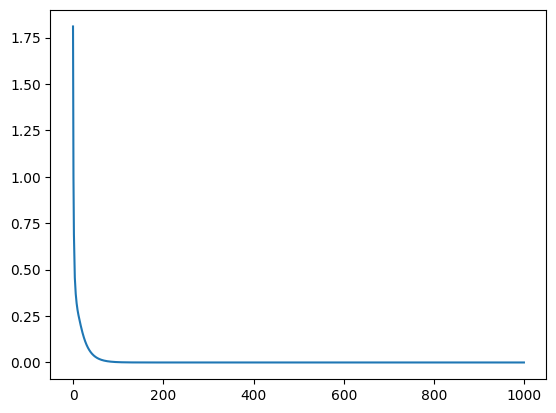

In [4]:
### nmf using douglas-rachford

W = np.random.rand(dimension, rankW )
X = np.random.rand(rankW, samples )
W_i = np.zeros((samples,dimension, rankW))
DR = DouglassRachford([projections.pos], [projections.bilinearMatrix])
### perform nmf
norm = []
for iter in range(1000):
    norm.append(np.linalg.norm( W @ X - Y))
    W_i = np.zeros((samples,dimension, rankW))
    for k in range(samples):
         x, w, y = DR.step_layer(X[:,k],W, Y[:,k])
         X[:,k] = x        
         W = W + (1/(k+1))*(w - W)
plt.plot(norm)
print("error", np.linalg.norm(W @ X - Y))

In [ ]:
ITERS = 1000
## alternating projections
### 2 layer neural network
### input layer 2 neurons hidden layer 2 neurons output layer 1 neuron
### approximate the xor function

# XOR dataset (inputs in R^2, labels in {0,1})
xor_X = np.array([[0, 1, 0, 1],
                  [0, 0, 1, 1]], dtype=np.float32)
xor_y = np.array([0, 1, 1, 0], dtype=np.float32).reshape(-1, 1)

print("xor_X:\n", xor_X)
print("xor_y:\n", xor_y)
### define weight matrices
W0 = np.random.rand(2,3)
W1 = np.random.rand(3)
b0 = 1
b1 = 1
delta = 1
def relu(x):
    return np.maximum(0,x)
### perform optimization
error = []
for iter in range(1000):
    err = []
    for k in range(len(xor_y)):
        # apply A constraints
        w0 = np.copy(W0)
        w1 = np.copy(W1)
        x_in = np.copy(xor_X[:,k]).reshape(2,1)
        x_in_with_bias = np.vstack((x_in, np.array([[b0]])))
        x_hidden = w0 @ x_in_with_bias
        x_hidden_with_bias = np.vstack((x_hidden, np.array([[b1]])))
        y_hidden = relu(x_hidden_with_bias)
        x_out = w1 @ y_hidden
        
        if xor_y[k] == 1:
            y_out = np.maximum(y_out, delta)
        else:
            y_out = np.minimum(y_out, 0)

        
        ## apply B constraints
        ##for output layer
        projection_w1, projection_y_hidden = bilinear_proj(w1,y_hidden.reshape(3), float(y_out))
        projection_y_hidden = projection_y_hidden.reshape(3,1)
        
        x_hidden_with_bias = projection_y_hidden
        x_hidden = projection_y_hidden[:2,:]
        
        ## for hidden layer
        x_new = np.zeros((3,2))
        for i in range(2):
            projection_w0, projection_x_in = bilinear_proj(w0[i,:],x_in_with_bias.reshape(3), projection_y_hidden[i][0])
            w0[i,:] = projection_w0
            x_new[:,i] = projection_x_in.reshape(1,3)
        x_in = np.mean(x_new, axis=1).reshape(3,1)
        
        ## consensus updates
        W0 = W0 + (1/(k+1))*(w0 - W0)
        W1 = W1 + (1/(k+1))*(projection_w1 - W1)
        b0 = b0 + (1/(k+1))*(x_in[2][0] - b0)
        b1 = b1 + (1/(k+1))*(x_hidden[2][0] - b1)
        if xor_y[k] == 1:
            err.append((x_out[0] - delta)**2 if x_out[0] < delta else 0)
        else:
            err.append((x_out[0])**2 if x_out[0] > 0 else 0)
    error.append(np.mean(err))
    print(iter)
    
import matplotlib.pyplot as plt
plt.plot(error)


xor_X:
 [[0. 1. 0. 1.]
 [0. 0. 1. 1.]]
xor_y:
 [[0.]
 [1.]
 [1.]
 [0.]]


/tmp/ipykernel_780427/2871929128.py:44: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  projection_w1, projection_y_hidden = bilinear_proj(w1,y_hidden.reshape(3), float(y_out))


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17


KeyboardInterrupt: 

In [142]:
## test the model
x_in = np.copy([0,0]).reshape(2,1)
x_in_with_bias = np.vstack((x_in, np.array([[b0]])))
x_hidden = W0 @ x_in_with_bias
x_hidden_with_bias = np.vstack((x_hidden, np.array([[b1]])))
y_hidden = relu(x_hidden_with_bias)
x_out = W1 @ y_hidden
print("input: [0,0], output:", x_out, "label: 0")

x_in =  np.array([[0,1]]).reshape(2,1)
x_in_with_bias = np.vstack((x_in, np.array([[b0]])))
x_hidden = W0 @ x_in_with_bias
x_hidden_with_bias = np.vstack((x_hidden, np.array([[b1]])))
y_hidden = relu(x_hidden_with_bias)
x_out = W1 @ y_hidden
print("input: [0,1], output:", x_out, "label: 1")

x_in =  np.array([[1,0]]).reshape(2,1)
x_in_with_bias = np.vstack((x_in, np.array([[b0]])))
x_hidden = W0 @ x_in_with_bias
x_hidden_with_bias = np.vstack((x_hidden, np.array([[b1]])))
y_hidden = relu(x_hidden_with_bias)
x_out = W1 @ y_hidden
print("input: [1,0], output:", x_out, "label: 1")

x_in =  np.array([[1,1]]).reshape(2,1)
x_in_with_bias = np.vstack((x_in, np.array([[b0]])))
x_hidden = W0 @ x_in_with_bias
x_hidden_with_bias = np.vstack((x_hidden, np.array([[b1]])))
y_hidden = relu(x_hidden_with_bias)
x_out = W1 @ y_hidden
print("input: [1,1], output:", x_out, "label: 0")


input: [0,0], output: [0.05422151] label: 0
input: [0,1], output: [0.2398876] label: 1
input: [1,0], output: [-0.0262481] label: 1
input: [1,1], output: [0.15941799] label: 0
